# RPS Classification에 PTQ (INT8) 적용

## 모듈 로딩

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.model_selection import train_test_split

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :2.0.2
TensorFlow Version :2.19.0
Matplotlib Version :3.10.0


## g-drive 마운트

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('g-drive mounted.')
    colab=True
except:
    print('local drive.')
    colab =False

Mounted at /content/drive
g-drive mounted.


In [ ]:
if colab :
  save_dir = '/content/drive/MyDrive/files/save/'
else :
  save_dir = '../files/save/'

## RPS 데이터셋 준비

In [ ]:
# files_path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  !unzip -q -o /content/drive/MyDrive/files/RPS_Dataset.zip
  files_path = '/content/RPS_Dataset'
else :
  files_path = '../files/RPS_Dataset'

## 폴더 별로 파일 읽어 데이터화 진행

In [ ]:
IMG_SIZE = 224

In [ ]:
%%time
first = True
for ind in range(0, 3, 1) :
    path = files_path + '/' + str(ind) + '/*.*'
    print(path)
    files = glob.glob(path)
    tmpx = np.array([(cv2.resize(cv2.cvtColor(cv2.imread(x, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB), (IMG_SIZE,IMG_SIZE))) for x in files])
    tmpy = np.array([ind] * len(files))

    xtrain, xtest, ytrain, ytest = train_test_split(tmpx, tmpy, test_size=0.2, random_state=123)

    if first == True:
        train_data = xtrain.copy()
        train_labels = ytrain.copy()
        test_data = xtest.copy()
        test_labels = ytest.copy()
        first = False
    else :
        train_data = np.concatenate((train_data, xtrain))
        train_labels = np.concatenate((train_labels, ytrain))
        test_data = np.concatenate((test_data, xtest))
        test_labels = np.concatenate((test_labels, ytest))

/content/RPS_Dataset/0/*.*
/content/RPS_Dataset/1/*.*
/content/RPS_Dataset/2/*.*
CPU times: user 7.43 s, sys: 764 ms, total: 8.19 s
Wall time: 8.25 s


## 데이터 확인

In [ ]:
# Normalization 처리 안함 (모델 내에서 -1 ~ 1로 변환 처리함)
# train_data = train_data / 255.0
# test_data = test_data / 255.0

print(train_data.shape)
print(train_labels.shape)
print(test_data.shape)
print(test_labels.shape)

(2172, 224, 224, 3)
(2172,)
(545, 224, 224, 3)
(545,)


## 모델 로딩 및 테스트

In [ ]:
savedModelName = 'RPS_MobileNetV2_Augmentation.keras'

In [ ]:
model = tf.keras.models.load_model (save_dir + savedModelName)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_1       │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_1          │ (None, 224, 224,  │          0 │ true_divide_1[0]… │
│ (Subtract)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ subtract_1[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis

 Total params: 2,751,051 (10.49 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,712 (1.25 MB)

In [ ]:
def Make_Result_Plot(suptitle, data, label, y_max):
    size = data.shape[0]//10
    fig_result, ax_result = plt.subplots(2,5,figsize=(18, 7))
    fig_result.suptitle(suptitle)
    for idx in range(10):
        cnt = idx * size + size//2
        ax_result[idx//5,idx%5].imshow(data[cnt].reshape((IMG_SIZE,IMG_SIZE, 3)))
        ax_result[idx//5,idx%5].set_title("test_data[{}] (label : {} / y : {})".format(cnt, label[cnt], y_max[cnt]))

18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 699ms/step


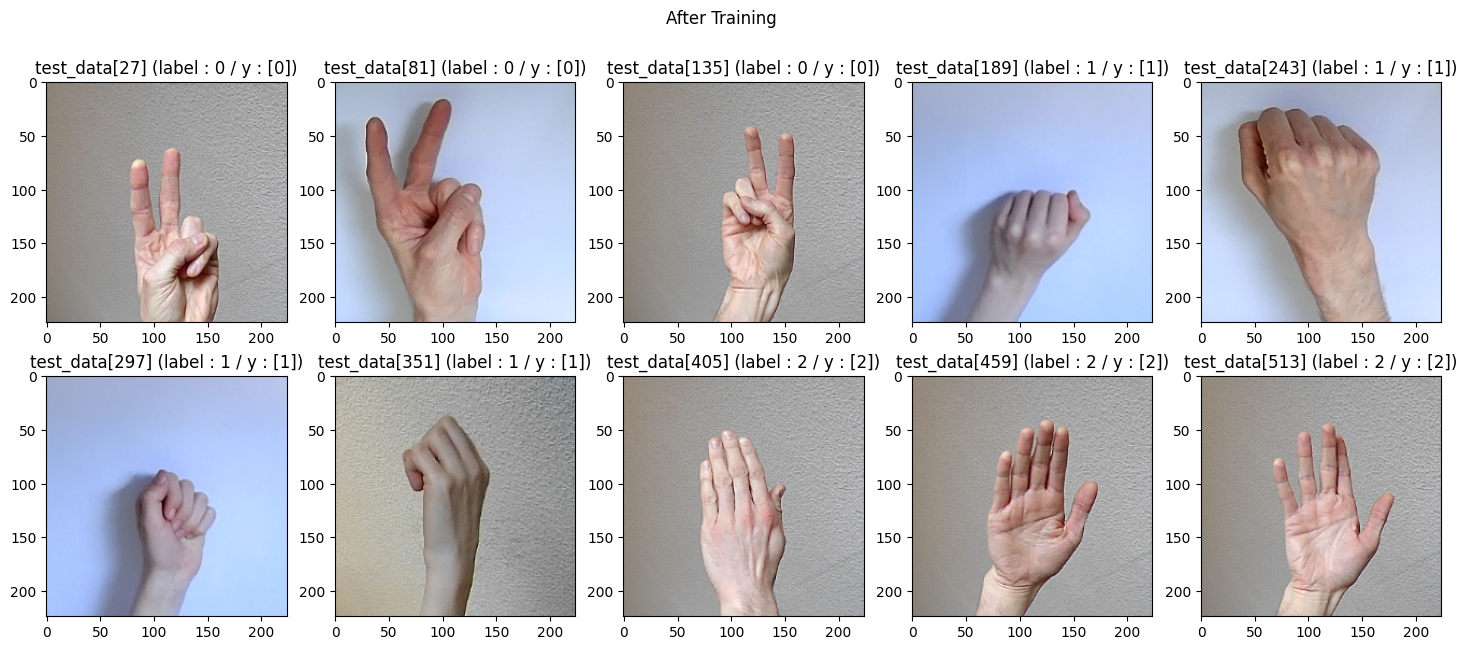

In [ ]:
y_out = model.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("After Training", test_data, test_labels, y_max)

## LiteRT 모델로 변환

In [ ]:
def representative_data_gen():
  ds = tf.data.Dataset.from_tensor_slices(train_data.astype(np.float32))
  ds = ds.shuffle(buffer_size=len(train_data))
  for input_value in ds.batch(1).take(100):
    yield [input_value]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
converter.representative_dataset = representative_data_gen

tflite_model = converter.convert()

Saved artifact at '/tmp/tmp7jmx9fmo'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  135726359360720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135726359362256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135726359362064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135726359362640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135726359361680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135726359361872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135726359363216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135726185235664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135726359362448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135726359363408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1357261852360

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


## LiteRT 모델을 파일로 저장

In [ ]:
tfliteFileName = 'RPS_MobileNetV2_Augmentation_PTQ_INT8.tflite'

In [ ]:
open(save_dir + tfliteFileName, 'wb').write(tflite_model)

2873040